In [1]:
import pandas as pd 
import numpy as np

method_colors = {
    "kt_gaussian": "#228B22",
    "kt_inverse_multiquadric": "#F5B027",
    "kt_sobolev": "gray",
    "kt_predictions": "#895129",
    "kt_stratified": "#ff1493",
    "kt_matern": "#59A14F",
    "arfpy": "#FF7DB0",
    "stein_thinning": "#B8DB80",
    "influence": "#5459AC",
    "iid": "#1F51FF",
}

results_aggregated = pd.read_csv("../package_metadata/results_strat_aggregation.csv")
all_methods = ['kt_gaussian', 'iid', 'kt_matern', 'kt_sobolev', 'kt_inverse_multiquadric', 'kt_predictions', 'stein_thinning', 'arfpy', 'influence', 'kt_stratified']
results_aggregated = results_aggregated[results_aggregated['method_total'].isin(all_methods)]

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean", 
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std", 
    "compression_time_mean",
    "compression_time_std"
]

baseline_method = "iid"

results_with_improvements = results_aggregated.copy()

group_cols = ['dataset_name', 'model_name', 'explainer_total', 'target_size', 'task']

for group_name, group in results_aggregated.groupby(group_cols):
    dataset_name, model_name, explainer_total, size, task = group_name

    baseline_row = group[group['method_total'] == baseline_method]
    if baseline_row.empty:
        continue

    baseline_idx = baseline_row.index[0]

    # ---------- SET BASELINE REDUCTIONS TO 0 ----------
    for metric in metrics_to_analyze:
        if metric in results_aggregated.columns:
            results_with_improvements.loc[
                baseline_idx, f'{metric}_pct_reduction'
            ] = 0.0

    # ---------- OTHER METHODS ----------
    for method in all_methods:
        if method == baseline_method:
            continue

        method_rows = group[group['method_total'] == method]
        if method_rows.empty:
            continue

        for idx in method_rows.index:
            for metric in metrics_to_analyze:
                if metric not in results_aggregated.columns:
                    continue

                baseline_val = baseline_row[metric].values[0]
                method_val = results_aggregated.loc[idx, metric]

                if (
                    pd.isna(baseline_val)
                    or pd.isna(method_val)
                    or baseline_val == 0
                ):
                    results_with_improvements.loc[
                        idx, f'{metric}_pct_reduction'
                    ] = np.nan
                    continue

                pct_reduction = (
                    (baseline_val - method_val)
                    / baseline_val
                ) * 100

                results_with_improvements.loc[
                    idx, f'{metric}_pct_reduction'
                ] = pct_reduction


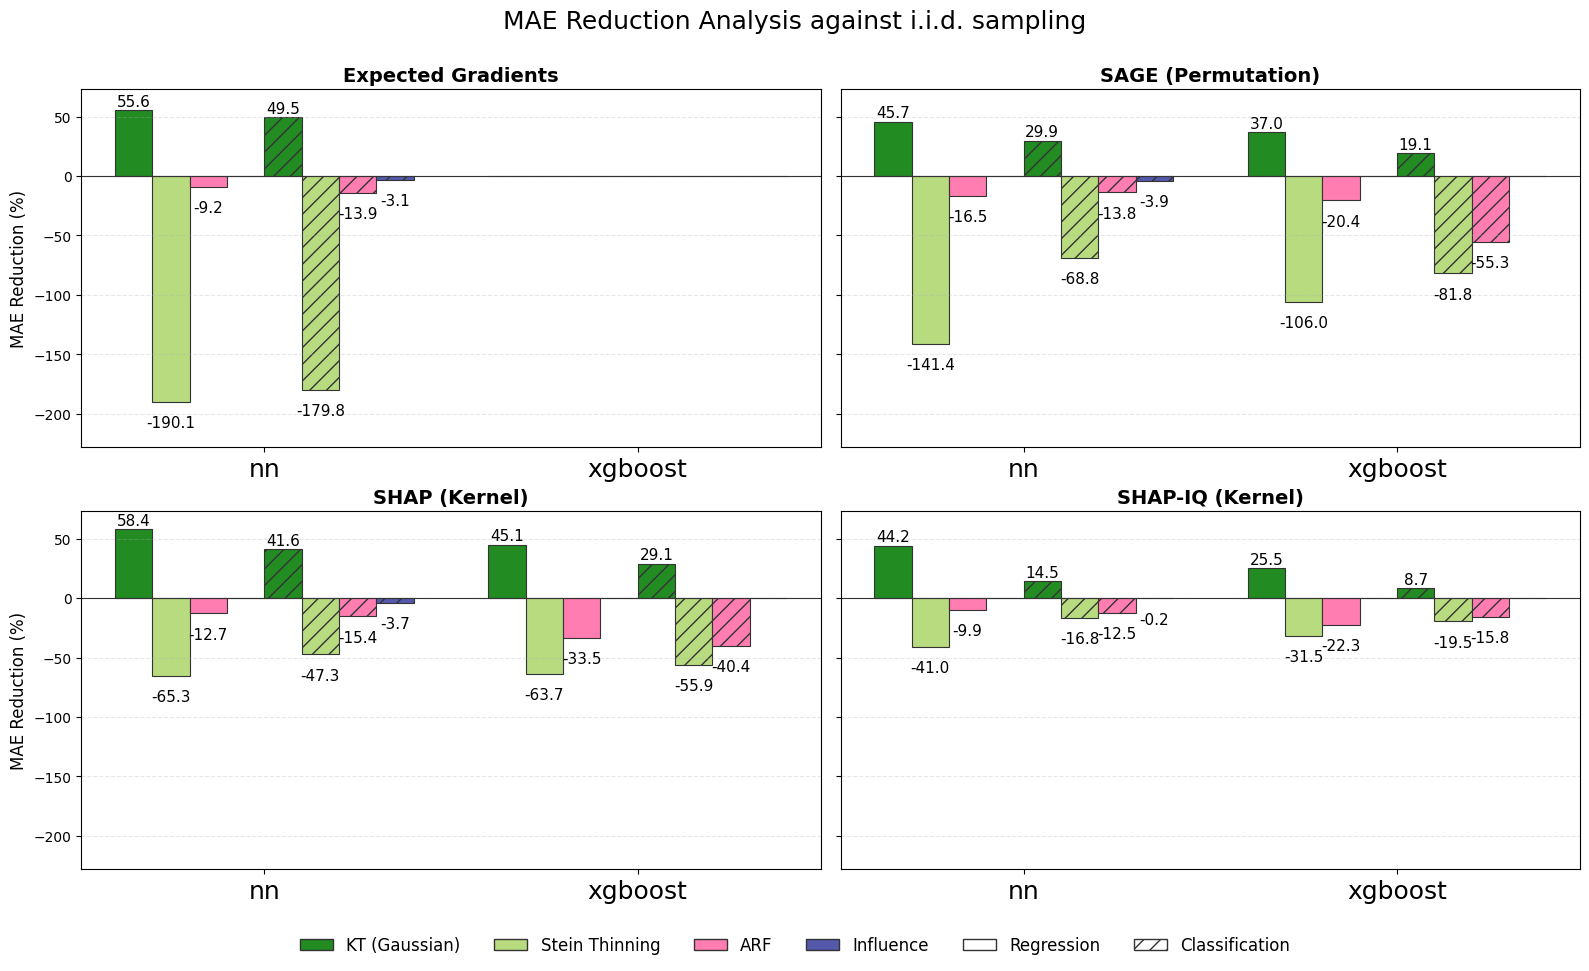

In [2]:
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

output_dir = "./baselines_comparison_plots"
os.makedirs(output_dir, exist_ok=True)

methods_to_plot = ['kt_gaussian', 'stein_thinning', 'arfpy', 'influence']
tasks = ["regression", "classification"]
task_hatch = {"regression": None, "classification": "//"}
method_labels = {"kt_gaussian": "KT (Gaussian)", "stein_thinning": "Stein Thinning", "arfpy": "ARF", "influence": "Influence"}
explainer_labels = {
    "expected_gradients": "Expected Gradients",
    "sage_permutation": "SAGE (Permutation)",
    "shap_kernel": "SHAP (Kernel)",
    "shapiq_kernel": "SHAP-IQ (Kernel)"
}
metric_ylabels = {"mae_mean": "MAE Reduction (%)"}
edgecolor = "#333333"
label_min_abs = 0.05

explainers = [e for e in explainer_labels if e in results_with_improvements["explainer_total"].unique()][:4]
models = sorted(results_with_improvements["model_name"].unique())

relevant_data = results_with_improvements[
    (results_with_improvements["method_total"].isin(methods_to_plot)) & 
    (results_with_improvements["explainer_total"].isin(explainers))
]
global_mae_mean = relevant_data.groupby(["explainer_total", "method_total", "task", "model_name"])["mae_mean_pct_reduction"].mean()
y_min_global = min(0, global_mae_mean.min() * 1.2)
y_max_global = global_mae_mean.max() * 1.25

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
axes_flat = axes.flatten()

bar_group_width = 0.8
total_bars = len(methods_to_plot) * len(tasks)
bar_w = bar_group_width / total_bars
pct_col = "mae_mean_pct_reduction"

for idx, explainer in enumerate(explainers):
    ax = axes_flat[idx]
    dfs = []
    for method in methods_to_plot:
        sub = results_with_improvements[
            (results_with_improvements["method_total"] == method) & 
            (results_with_improvements["explainer_total"] == explainer)
        ]
        if sub.empty: continue
        df_method = sub.groupby(["task", "model_name"])[[pct_col]].mean().reset_index()
        df_method.rename(columns={pct_col: "mean_improvement"}, inplace=True)
        df_method["method_total"] = method
        dfs.append(df_method)
    
    if not dfs: continue
    df_all = pd.concat(dfs, ignore_index=True)
    
    x = np.arange(len(models))
    bar_i = 0
    
    for task in tasks:
        for method in methods_to_plot:
            tmp = df_all[(df_all["method_total"] == method) & (df_all["task"] == task)]
            values = [
                tmp.loc[tmp["model_name"] == m, "mean_improvement"].values[0] 
                if m in tmp["model_name"].values else 0.0 
                for m in models
            ]
            xpos = x + (bar_i - (total_bars - 1) / 2) * bar_w
            bars = ax.bar(xpos, values, bar_w, color=method_colors[method], hatch=task_hatch[task], edgecolor=edgecolor, linewidth=0.8)
            
            for b in bars:
                h = b.get_height()
                if abs(h) < label_min_abs: continue
                ax.text(
                    b.get_x() + b.get_width()/2, 
                    h + (0.01 * y_max_global if h >= 0 else -0.05 * abs(y_min_global)), 
                    f"{h:.1f}", 
                    ha="center", 
                    va="bottom" if h >= 0 else "top", 
                    fontsize=11, 
                    rotation=0
                )
            bar_i += 1
            
    ax.set_title(explainer_labels[explainer], fontsize=14, fontweight='bold')
    if idx % 2 == 0:
        ax.set_ylabel(metric_ylabels["mae_mean"], fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=18)
    ax.set_ylim(y_min_global, y_max_global)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.axhline(0, color=edgecolor, linewidth=0.8)

legend_handles = [
    Patch(facecolor=method_colors[m], edgecolor=edgecolor, label=method_labels[m]) 
    for m in methods_to_plot
] + [
    Patch(facecolor="white", edgecolor=edgecolor, hatch=task_hatch[t], label=t.capitalize()) 
    for t in tasks
]

fig.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, 0.02), ncol=len(legend_handles), frameon=False, fontsize=12)
plt.suptitle("MAE Reduction Analysis against i.i.d. sampling", fontsize=18, y=0.98)
plt.tight_layout()
plt.subplots_adjust(bottom=0.12, top=0.9)
pdf_path = os.path.join(output_dir, "baselines_mae_reduction_2x2.pdf")
plt.savefig(pdf_path, dpi=300, format="pdf")
plt.show()

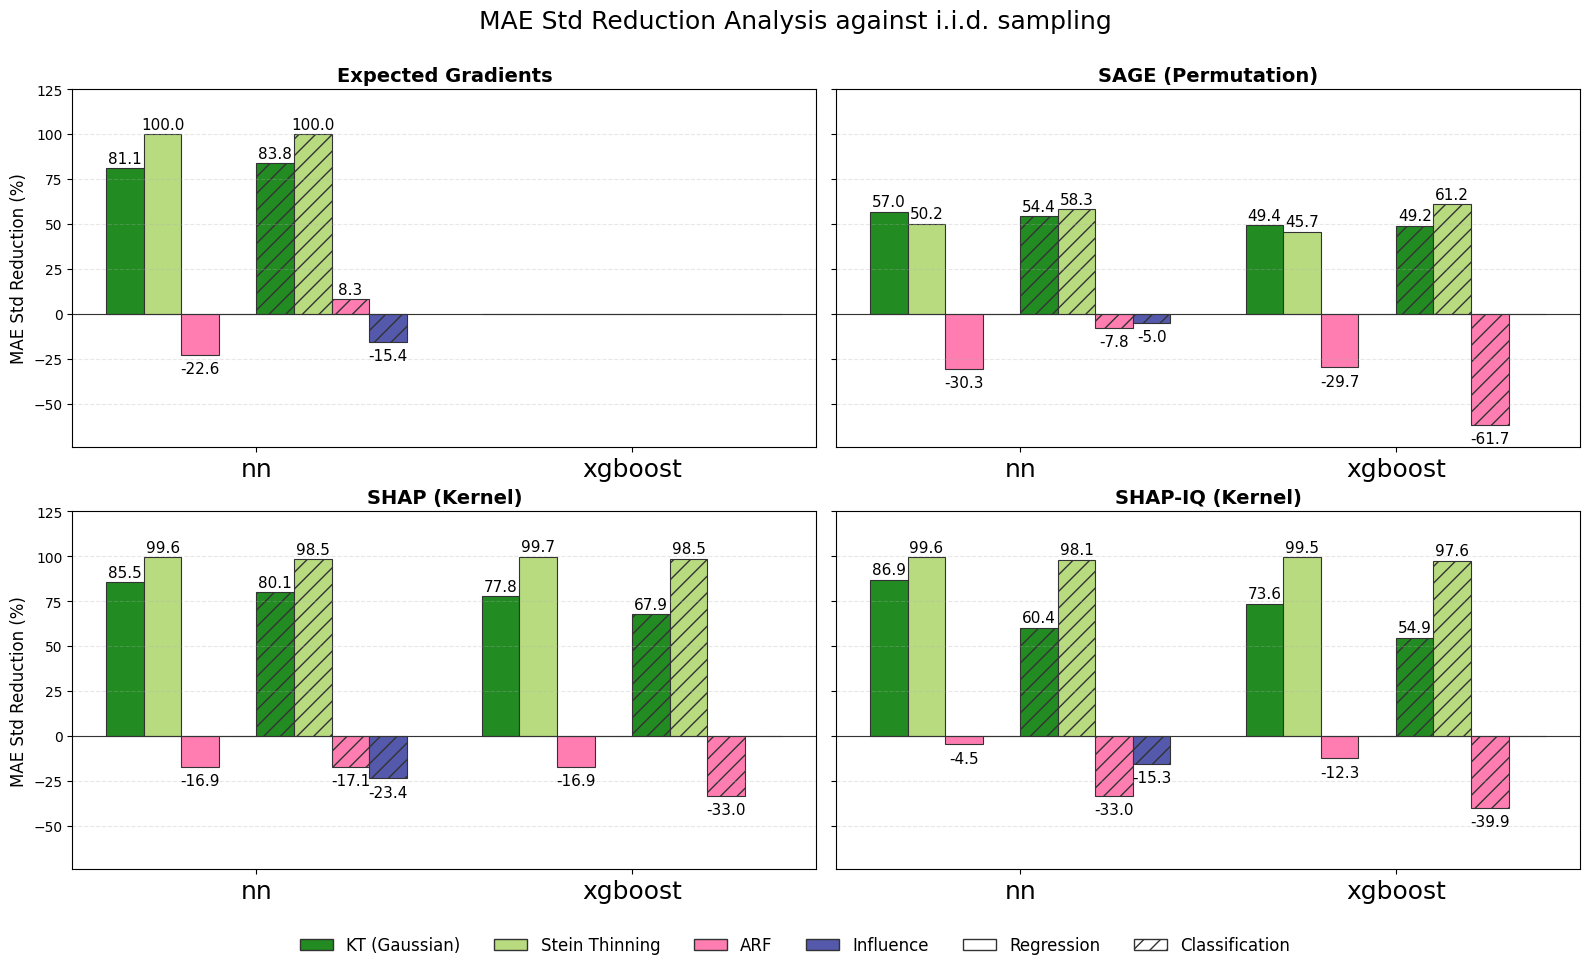

In [4]:
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

output_dir = "./baselines_comparison_plots"
os.makedirs(output_dir, exist_ok=True)

methods_to_plot = ['kt_gaussian', 'stein_thinning', 'arfpy', 'influence']
tasks = ["regression", "classification"]
task_hatch = {"regression": None, "classification": "//"}
method_labels = {"kt_gaussian": "KT (Gaussian)", "stein_thinning": "Stein Thinning", "arfpy": "ARF", "influence": "Influence"}
explainer_labels = {
    "expected_gradients": "Expected Gradients",
    "sage_permutation": "SAGE (Permutation)",
    "shap_kernel": "SHAP (Kernel)",
    "shapiq_kernel": "SHAP-IQ (Kernel)"
}

metric_to_eval = "mae_std"
pct_col = f"{metric_to_eval}_pct_reduction"
metric_ylabels = {metric_to_eval: "MAE Std Reduction (%)"}

edgecolor = "#333333"
label_min_abs = 0.05

explainers = [e for e in explainer_labels if e in results_with_improvements["explainer_total"].unique()][:4]
models = sorted(results_with_improvements["model_name"].unique())

relevant_data = results_with_improvements[
    (results_with_improvements["method_total"].isin(methods_to_plot)) & 
    (results_with_improvements["explainer_total"].isin(explainers))
]
global_vals = relevant_data.groupby(["explainer_total", "method_total", "task", "model_name"])[pct_col].mean()
y_min_global = min(0, global_vals.min() * 1.2)
y_max_global = global_vals.max() * 1.25

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
axes_flat = axes.flatten()

bar_group_width = 0.8
total_bars = len(methods_to_plot) * len(tasks)
bar_w = bar_group_width / total_bars

for idx, explainer in enumerate(explainers):
    ax = axes_flat[idx]
    dfs = []
    for method in methods_to_plot:
        sub = results_with_improvements[
            (results_with_improvements["method_total"] == method) & 
            (results_with_improvements["explainer_total"] == explainer)
        ]
        if sub.empty: continue
        
        df_method = sub.groupby(["task", "model_name"])[[pct_col]].mean().reset_index()
        df_method.rename(columns={pct_col: "mean_improvement"}, inplace=True)
        df_method["method_total"] = method
        dfs.append(df_method)
    
    if not dfs: continue
    df_all = pd.concat(dfs, ignore_index=True)
    
    x = np.arange(len(models))
    bar_i = 0
    
    for task in tasks:
        for method in methods_to_plot:
            tmp = df_all[(df_all["method_total"] == method) & (df_all["task"] == task)]
            values = [
                tmp.loc[tmp["model_name"] == m, "mean_improvement"].values[0] 
                if m in tmp["model_name"].values else 0.0 
                for m in models
            ]
            
            xpos = x + (bar_i - (total_bars - 1) / 2) * bar_w
            bars = ax.bar(xpos, values, bar_w, color=method_colors[method], hatch=task_hatch[task], edgecolor=edgecolor, linewidth=0.8)
            
            for b in bars:
                h = b.get_height()
                if abs(h) < label_min_abs: continue
                ax.text(
                    b.get_x() + b.get_width()/2, 
                    h + (0.01 * y_max_global if h >= 0 else -0.05 * abs(y_min_global)), 
                    f"{h:.1f}", 
                    ha="center", 
                    va="bottom" if h >= 0 else "top", 
                    fontsize=11, 
                    rotation=0
                )
            bar_i += 1
            
    ax.set_title(explainer_labels[explainer], fontsize=14, fontweight='bold')
    if idx % 2 == 0:
        ax.set_ylabel(metric_ylabels[metric_to_eval], fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=18)
    ax.set_ylim(y_min_global, y_max_global)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.axhline(0, color=edgecolor, linewidth=0.8)

legend_handles = [
    Patch(facecolor=method_colors[m], edgecolor=edgecolor, label=method_labels[m]) 
    for m in methods_to_plot
] + [
    Patch(facecolor="white", edgecolor=edgecolor, hatch=task_hatch[t], label=t.capitalize()) 
    for t in tasks
]

fig.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, 0.02), ncol=len(legend_handles), frameon=False, fontsize=12)
plt.suptitle("MAE Std Reduction Analysis against i.i.d. sampling", fontsize=18, y=0.98)
plt.tight_layout()
plt.subplots_adjust(bottom=0.12, top=0.9)

pdf_path = os.path.join(output_dir, "baselines_mae_std_reduction_2x2.pdf")
plt.savefig(pdf_path, dpi=300, format="pdf")
plt.show()